# Neural Network - 1D-CNN excecution

This notebook trains neural network models based on the paper [incluir citas].

The model implemented is `1dcnn` → Conv1D block + 4 Dense layers + Batch Normalization + Dropout.

This program:
1. 
2. 
3. 
4. 
5. 

This notebook expects the files generated by the preprocessing notebook:

- `Dataset/train/preprocessed_train.csv`
- `Dataset/test/preprocessed_test.csv`


## Imports

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

from pathlib import Path

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger

## 1. Load preprocessed datasets

In [52]:
train_df = pd.read_csv("../../Dataset/train/preprocessed_train.csv")
test_df = pd.read_csv("../../Dataset/test/preprocessed_test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (3918, 12)
Test shape: (980, 12)


,alcohol,density,residual sugar,total sulfur dioxide,free sulfur dioxide,chlorides,citric acid,fixed acidity,pH,sulphates,volatile acidity,quality
0,0.811436,-1.015152,-0.396463,0.273654,0.090254,-0.876675,-0.777631,-1.476971,0.727373,-1.572934,-0.676949,7
1,1.954627,-1.633570,-0.945154,-0.762947,0.265528,-0.502390,-0.199185,-0.773832,0.465637,-0.870325,0.225769,7
2,-0.903350,0.248282,-0.376867,0.839073,1.492444,9.088661,-0.116550,-0.539453,-0.450439,-0.079891,-0.075137,5
3,0.893092,-1.477303,-1.023539,-0.998539,-0.201869,-0.455604,0.048721,-0.656643,-0.843043,2.203587,-0.576647,6
4,1.056405,-1.181394,-0.435656,-0.904302,0.090254,-0.783104,-1.438712,-1.828540,0.727373,-1.133804,0.225769,8


## 2. Separate attributes and labels

In [53]:
X_train = train_df.drop("quality", axis=1).astype("float32")
y_train = train_df["quality"].astype("int32")

X_test = test_df.drop("quality", axis=1).astype("float32")
y_test = test_df["quality"].astype("int32")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTest class distribution:")
print(y_test.value_counts().sort_index())


X_train: (3918, 11)
y_train: (3918,)
X_test: (980, 11)
y_test: (980,)

Training class distribution:
quality
3      16
4     130
5    1166
6    1758
7     704
8     140
9       4
Name: count, dtype: int64

Test class distribution:
quality
3      4
4     33
5    291
6    440
7    176
8     35
9      1
Name: count, dtype: int64


## 3. Encode labels

Wine quality labels are not always `0, 1, 2, ...`.

For neural networks, we encode them before training.

Example:

`3 → 0`, `4 → 1`, `5 → 2`, etc.


In [66]:
encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train).astype("int32")
y_test_encoded = encoder.transform(y_test).astype("int32")

num_classes = len(encoder.classes_)
num_attributes = X_train.shape[1]

# print("Classes on dataset:", encoder.classes_)
# print("Number of classes:", num_classes)
# print("Number of attributes:", num_attributes)

print("Encoder classes:")
print(encoder.classes_)

Encoder classes:
[3 4 5 6 7 8 9]


## 4. Import model

In [55]:
sys.path.append(os.path.abspath("../../"))

from models.oneD_CNN_model import create_model 

model = create_model(num_classes=num_classes, num_attributes=num_attributes)

model.summary()

Model: "wine_quality_1d_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_block (Conv1D)           │ (None, 11, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 352)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        45,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_128                  │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_128 (Activation)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_128 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_64                   │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_64 (Activation)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_32                   │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_32 (Activation)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ quality_output (Dense)          │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,191 (223.40 KB)

 Trainable params: 56,743 (221.65 KB)

 Non-trainable params: 448 (1.75 KB)

## 5. Compile model

In [56]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 6. Train model & callbacks

In [57]:
best_model_checkpoint = ModelCheckpoint(
    filepath="../../models/1D_CNN_checkpoints/best_1D_CNN_model.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

# save model certain N epochs
class SaveModelEveryNEpochs(tf.keras.callbacks.Callback):
    def __init__(self, save_dir, every=10, prefix="1D_CNN"):
        super().__init__()
        self.save_dir = Path(save_dir)
        self.every = every
        self.prefix = prefix
        self.save_dir.mkdir(parents=True, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        current_epoch = epoch + 1

        if current_epoch % self.every == 0:
            logs = logs or {}
            val_loss = logs.get("val_loss")

            if val_loss is not None:
                filename = f"{self.prefix}_epoch_{current_epoch}_val_loss_{val_loss:.4f}.keras"

            model_path = self.save_dir / filename
            self.model.save(model_path)

periodic_checkpoint = SaveModelEveryNEpochs(
    save_dir="../../models/1D_CNN_periodic_checkpoints",
    every=10
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

csv_logger = CSVLogger(
    filename="../../models/1D_CNN_periodic_checkpoints/1D_CNN_training_log.csv",
    append=False
)

callbacks = [
    best_model_checkpoint,
    periodic_checkpoint,
    early_stopping,
    csv_logger
]

history = model.fit(
    X_train,
    y_train_encoded,
    epochs=100,
    batch_size=32,
    validation_split=.2,
    callbacks=callbacks
)


Epoch 1/100
88/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3060 - loss: 1.7658
Epoch 1: val_loss improved from None to 1.47651, saving model to ../../models/1D_CNN_checkpoints/best_1D_CNN_model.keras

Epoch 1: finished saving model to ../../models/1D_CNN_checkpoints/best_1D_CNN_model.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3973 - loss: 1.5422 - val_accuracy: 0.4681 - val_loss: 1.4765
Epoch 2/100
88/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4752 - loss: 1.2895
Epoch 2: val_loss improved from 1.47651 to 1.25313, saving model to ../../models/1D_CNN_checkpoints/best_1D_CNN_model.keras

Epoch 2: finished saving model to ../../models/1D_CNN_checkpoints/best_1D_CNN_model.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4860 - loss: 1.2626 - val_accuracy: 0.5217 - val_loss: 1.2531
Epoch 3/100
90/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5014 - loss: 1.1895
Epoch 3: val_loss improved from 1.25313 to 1.16195, saving model to ../../models/1D_CNN_

## 7. Training behavior plots

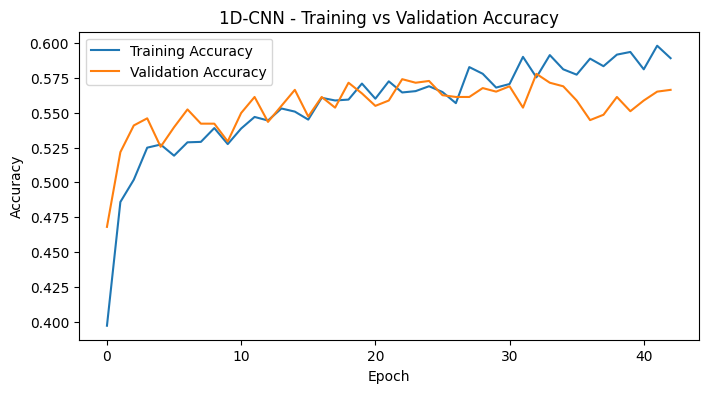

In [58]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("1D-CNN - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


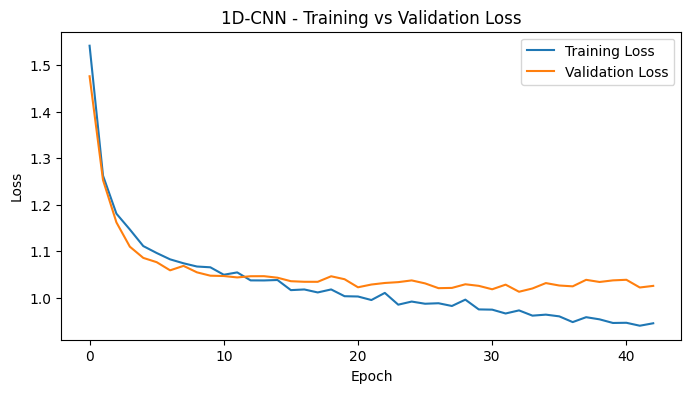

In [59]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("1D-CNN - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


## 8. Predictions

In [60]:
y_train_pred_probs = model.predict(X_train)
y_test_pred_probs = model.predict(X_test)

print(y_test_pred_probs[:5])

y_train_pred = np.argmax(y_train_pred_probs, axis=1)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
[[4.0889927e-04 2.1587558e-02 6.9679844e-01 2.7898863e-01 2.1703299e-03
  4.5803521e-05 3.3768987e-07]
 [2.2929064e-04 3.0710932e-03 3.9483242e-02 6.2202752e-01 3.0356210e-01
  3.1233247e-02 3.9361740e-04]
 [3.6204837e-02 1.4790061e-01 4.2238039e-01 3.4841719e-01 3.4237660e-02
  9.6967872e-03 1.1625551e-03]
 [1.5025029e-03 6.7262501e-03 9.0209685e-02 5.1385546e-01 2.8361934e-01
  1.0205412e-01 2.0326981e-03]
 [1.4645237e-04 5.7341713e-03 1.4516296e-02 3.1217942e-01 4.9823073e-01
  1.6777913e-01 1.4138133e-03]]


## 9. Metrics

In [61]:
def evaluate_model(y_true, y_pred, dataset_name):
    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"{dataset_name} Results")
    print("---------------------")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    return {
        "dataset": dataset_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }


In [62]:
train_metrics = evaluate_model(y_train_encoded, y_train_pred, "Training")
print()
test_metrics = evaluate_model(y_test_encoded, y_test_pred, "Test")

Training Results
---------------------
Accuracy : 0.6276
Precision: 0.6046
Recall   : 0.6276
F1 Score : 0.6055

Test Results
---------------------
Accuracy : 0.5602
Precision: 0.5257
Recall   : 0.5602
F1 Score : 0.5382


## 10. Classification report

In [63]:
print(
    classification_report(
        y_test_encoded,
        y_test_pred,
        target_names=[str(label) for label in encoder.classes_],
        zero_division=0
    )
)


              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.25      0.03      0.05        33
           5       0.58      0.62      0.59       291
           6       0.57      0.66      0.61       440
           7       0.50      0.44      0.47       176
           8       0.00      0.00      0.00        35
           9       0.00      0.00      0.00         1

    accuracy                           0.56       980
   macro avg       0.27      0.25      0.25       980
weighted avg       0.53      0.56      0.54       980



## 11. Confusion matrix

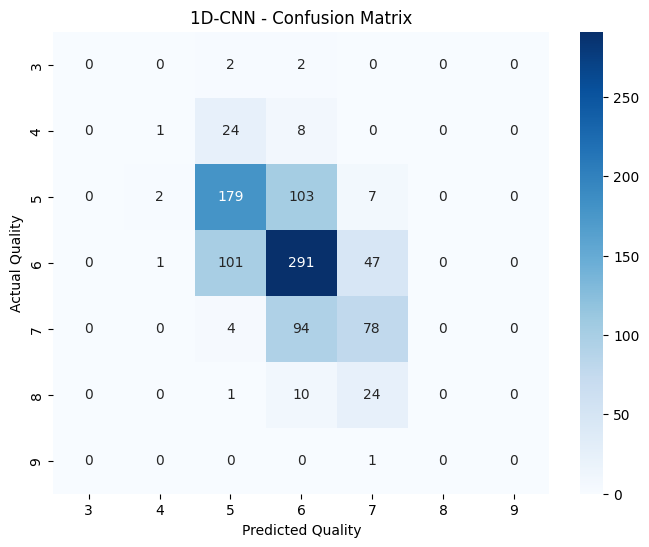

In [64]:
cm = confusion_matrix(
    y_test_encoded,
    y_test_pred
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("1D-CNN - Confusion Matrix")
plt.xlabel("Predicted Quality")
plt.ylabel("Actual Quality")
plt.show()
